In [ ]:
import geopops
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import scipy.stats as stats
import starsim as ss
import sciris as sc
from measles_geopops import Measles, custom_seeding, plot_measles, Isolate_inf, get_children, Quarantine_sib, Quarantine_contacts, CloseSchools
import warnings
warnings.resetwarnings()
warnings.filterwarnings(
    "ignore",
    message=r"FNV hashing is not implemented in Numba.*",
    category=UserWarning,
    module=r"numba\.cpython\.hashing",
)

# 4.0 Measles with quarantine

In this notebook, we'll explore the custom measles class and along with four isolation/quarantine strategies:
1) Isolate infected individuals only
2) Isolate infected individuals and quarantine their "siblings" (i.e, other children in same household)
3) Isolate infected individuals and quarantine their siblings and school contacts 
4) Closing schools of infected individuals

## 4.1 Custom Measles class
Think of this measles example as a starting point of an iterative, community-building modeling exercise. GeoPops and Starsim provide a customizable framework for a detailed, context-specific scenario model, but this version is the first draft! There is still a lot that can be added in collaboration with public health researchers and officials on the ground to make the model more realistic.

Here's a refresher of how Starsim transmission works from previous notebooks:

For each time step, Starsim knows who the infectious agents are (sources) and who the susceptible agents are (targets). For every contact (i.e., edge) between agents, there is a probability of infection every time step if one of those agents is infectious. To calculate that probability, Starsim scales the base infectiousness of the disease by:
* The source’s relative transmissability
* The target’s relative susceptibility
* The effective transmission strength of that contact (edge_weight)

To decide if a target agent gets infected, Starsim draws a uniform random number between 0 and 1 for that contact.
If the probability is larger than the random draw, that contact is marked as having caused an infection. So, for each time step we have a list of infectious sources and a list of targets who got infected.

When an agent enters a disease state (e.g., Infectious), Starsim samples and stores the future time that agent will transition out of that state (e.g., using the duration of infection). When that stored time is reached, the agent transitions to the next state (e.g., Recovered).

The custom measles class is called `Measles()` and is stored in `measles_geopops.py` builds on Starsim's base SIR class stored in the Starsim file `diseases.py`. You can customize diseases in many ways (adding disease compartments or subgroup-specific parameters). Our custom measles class includes:
* A state for Exposed individuals
* Age-dependent relative transmissability and relative susceptability
* Reduced susceptibility for vaccinated individuals
* A custom function to seed infections by age and school

Here are the main disease parameters used in `Measles()`:

| Parameter | Definition | Default value |
| -------- | -------- | -------- |
| beta | Disease's base infectiousness, scaled by rel_trans, rel_sus, and edge_weight to determine probability of infection | 0.9 |
| dur_exp | Duration of Exposed state (not contagious), drawn from normal distribution | 10.0 |
| dur_inf | Duration of Infecitous state (contagious), drawn from normal distribution | 8.0 |
| vax_eff | Effectiveness of vaccine at reducing susceptibility, scales rel_sus by 1-vax_eff | 0.97 |
| rel_sus_babies | Relative susceptability of ages <2 | 1.0 |
| rel_sus_young | Relative susceptability of ages 2-4 | 1.0 |
| rel_sus_school | Relative susceptability of ages 5-18 | 1.0 |
| rel_sus_adults | Relative susceptability of ages >18| 0.0 |
| rel_trans_babies | Relative transmissibility of ages <2 | 1.0 |
| rel_trans_young | Relative transmissibility of ages 2-4 | 1.0 |
| rel_trans_school | Relative transmissibility of ages 5-18 | 1.0 |
| rel_trans_adults | Relative transmissibility of ages >18| 0.0 |

[Hopkins Medicine](https://www.hopkinsmedicine.org/health/conditions-and-diseases/measles-what-you-should-know#:~:text=Nine%20out%20of%2010%20unimmunized,room%20if%20they%20are%20unimmunized.) reports 9 out of 10 unimmunized children will contract the virus if they come into contact with an infectious individual. So we set the base infectiousness, `beta`, to be 0.9. The probability of infection for an exposed *unimunized* 5 year old in our model is therefore 0.9. And the probability of infection for an exposed *imunized* 5 year old is 0.027.
* Unimmunized: beta * rel_sus_school * rel_trans_school * edge_weight equals 0.9 (0.9 * 1 * 1 * 1 = 0.9)
* Immunized: beta * rel_sus_school * (1 - vax_eff) * rel_trans_school * edge_weight equals 0.027 (0.9 * 1 * (1 - 0.97) * 1 * 1 = 0.027)

Note: By default, Starsim does not clamp the probability of transmission to be less than one. The random draw is betwen 0 and 1. This means that a transmission will definitely happen if the product of disease beta, rel_sus, rel_trans, and edge_weight is over 1. Here's a [guide](https://docs.starsim.org/user_guide/advanced_time.html#probability-rates) to Starsim rates and probabilities.

The [CDC](https://www.cdc.gov/measles/hcp/communication-resources/clinical-diagnosis-fact-sheet.html#:~:text=Measles%20is%20a%20highly%20contagious%20respiratory%20virus,more%20than%20104%C2%B0%20F%20when%20rash%20appears) describes the following progression of illness, which informs `dur_exp` and `dur_inf` in the model.

| Measles progression | Days | Model compartment |
| -------- | -------- | -------- |
| Incubation, no symptoms | 1-10 | Exposed |
| Prodromal symptoms, cough/fever | 11-14 | Infectious |
| Rash | 15-18 | Infectious |
| Rash clears |19-21 | Recovered |

To simplify the Spartanburg example, we also assume
* Only children under 18 can get infected, so we set `rel_sus_adults`=0 and `rel_trans_adults`=0
* Infections only occur in the home and at school so we don't need to include the work and group quarters networks in the sim
* No one dies from measles, probability of death is 0

Measles quarantine lasts [21 days](https://www.thestate.com/news/state/south-carolina/article313654527.html) after a known exposure, and according to [SC DPH](https://dph.sc.gov/news/tuesday-measles-update-dph-reports-89-new-measles-cases-upstate-bringing-outbreak-total-789) there were 557 students quarantined on of 25 Jan 2026.

Initial prevalence is defined with a custom seeding function stored in `measles_geopops.py`. [Two schools](https://dph.sc.gov/news/measles-update-dph-confirms-locations-spartanburg-county-outbreak-media-briefing-take-place) in Spartanburg confirmed measles cases in the beginning of October 2025. One of these schools is a private school, and GeoPops currently only has public schools. So the custom seeding function explained in `4_measles_seeding.ipynb` seeds 30 exposed students in this public school (Fairforest Elementary). The custom seeding function is a default in the `Measles()` class and won't be adjusted in this notebook. But you can play around with targeting different schools or changing the number of seed infections in `4_measles_seeding.ipynb`.

This notebook focuses on testing isolation/quarantine strategies:
1) Isolate infected individuals only
2) Isolate infected individuals and quarantine their "siblings" (i.e, other children in same household)
3) Isolate infected individuals and quarantine all their siblings and school contacts
4) Closing schools of infected individuals

## 4.2 Base model (no isolation/quarantine)

The next cell defines `sim1` (no isolation/quarantine). After running it once, you can try changing disease parameter values to see how they impact infection curves.

Note: In the plots, "Infectious" refers to the number of agents currently in the Infectious state (I), and "cumulative infections" means the cumulative sum of new infections.

In [2]:
# Load the people object
ppl = ss.load('data/pop_export/starsim/ppl_vax.pkl')

# Define the networks with edge weights
# Default assumes same relative edge weights, but you can change this
h = geopops.ForStarsim.GPNetwork(name='homenet', edge_weight=1.0) 
s = geopops.ForStarsim.GPNetwork(name='schoolnet', edge_weight=1.0)
# already defined between-school network as b

measles_pars = sc.objdict(beta      = 0.9, # disease's base infectiousness (scaled by rel_trans, rel_sus, and edge_weight)
                          dur_exp   = ss.normal(10.0), # duration of Exposed state, in this model not infectious, drawn from normal distribution, default=10
                          dur_inf   = ss.normal(8.0), # duration of Infectious state, drawn from normal distribution, default=8
                          vax_eff   = 0.97, # effectiveness of vaccine, scales rel_sus by 1-vax_eff, default=0.97
                          rel_sus_babies   = 1.0, # relative susceptability of ages <2, default=1
                          rel_sus_young    = 1.0, # relative susceptability of ages 2-4, default=1
                          rel_sus_school   = 1.0, # relative susceptability of ages 5-17, default=1
                          rel_sus_adults   = 0.0, # relative susceptability of ages >18, default=0
                          rel_trans_babies = 1.0, # relative transmissability of ages <2, default=1
                          rel_trans_young  = 1.0, # relative transmissability of ages 2-4, default=1
                          rel_trans_school = 1.0, # relative transmissability of ages 5-17, default=1
                          rel_trans_adults = 0.0, # relative transmissability of ages >18, default=0
                          )


*** Running ForStarsim.GPNetwork._create_networks() ***
Network csv files created and saved successfully


Initializing sim with 356923 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.32 s)  ———————————————————— 4%
  Running 20.0 (20/301) (0.59 s)  •——————————————————— 7%
  Running 30.0 (30/301) (0.88 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (1.15 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (1.42 s)  •••————————————————— 17%
  Running 60.0 (60/301) (1.68 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (1.95 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (2.21 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (2.48 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (2.76 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (3.02 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (3.30 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (3.57 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (3.84 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (4.12 s)  ••••••••••—————————— 50%
  Running 16

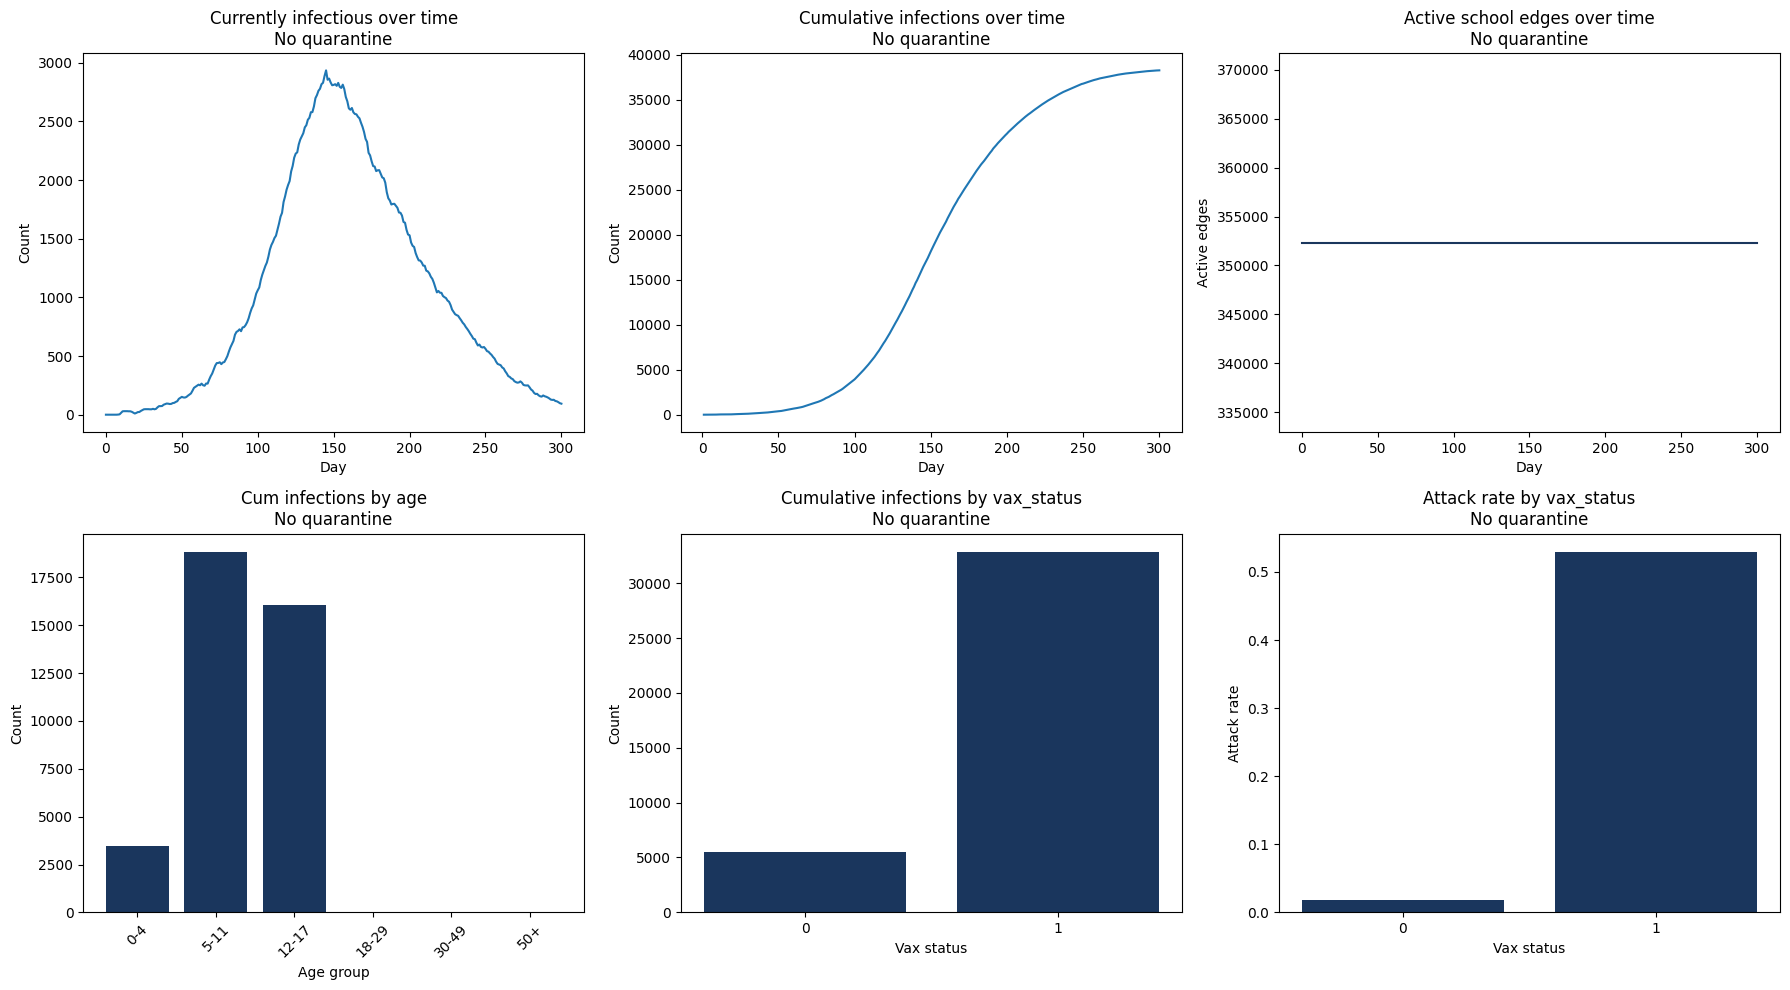

In [3]:
# Run sim with no isolation/quarantine
sim1 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  = 300, dt = 1.0),
    people  = ppl,
    networks = [h, s,],
    diseases = [Measles(measles_pars)],  # use custom Measles model
    ).run()

# Store results
res1 = sim1.results

# Plot results
plot_measles(sim1, res1, label='No quarantine')

## 4.3 Isolate infectious only
It's unlikely that no one would isolate during a measles outbreak. In this section, we simulate isolating the infectious individual only. Several of their contacts would likely also stay home, but we'll simulate this scenario first so we can compare it to other strategies later. 

`measles_geopops.ipynb` includes a custom ss.Intervention() class called `Isolate_inf()`. It's meant to simulate a scenario where only infectious individuals quarantine. Here's the logic and input parameters:

* The proportion of infected individuals who comply with isolation is set with `compliance`
* On each timestep, identify agents who are currently in the infectious state
* If the time since they became infectious is beyond `days_since_infectious`, they start to "isolate"
* This means their edges in the school network will be turned "off" (i.e., set to 0) until `dur_quarantine` passes

Any school edge where either endpoint is an isolating agent has its edge weight set to 0 (removing those school contacts for that day). Edge weights are set back to one when both contacts are no longer in isolation. The cell below defines the Isolate_inf() intervention inside the sim. After running it once, try changing the inputs of Isolate_inf() and running again.

Initializing sim with 356923 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.17 s)  ———————————————————— 4%
  Running 20.0 (20/301) (0.41 s)  •——————————————————— 7%
  Running 30.0 (30/301) (0.68 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (0.97 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (1.26 s)  •••————————————————— 17%
  Running 60.0 (60/301) (1.55 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (1.84 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (2.14 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (2.43 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (2.73 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (3.03 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (3.33 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (3.63 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (3.94 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (4.24 s)  ••••••••••—————————— 50%
  Running 16

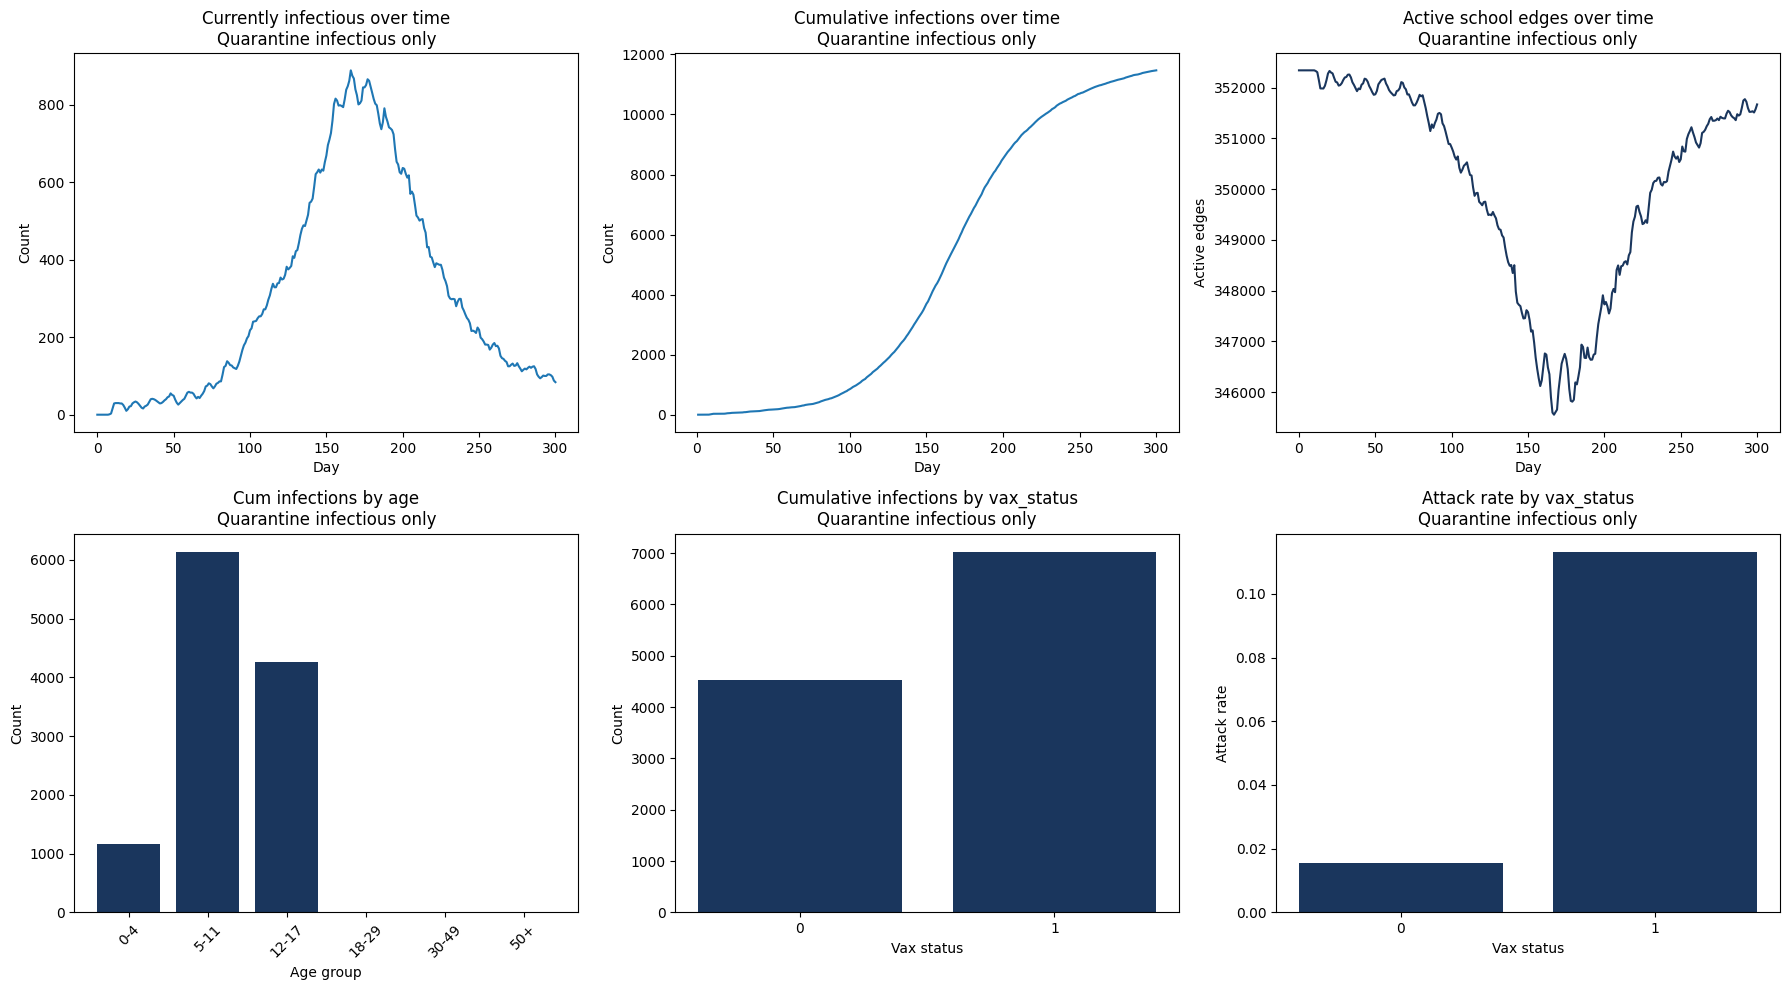

In [ ]:
# Run Measles model with Isolation of infected only intervention
sim2 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s,],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = Isolate_inf(days_since_infectious=3, # How many days after becoming infectious do people start quarantining? default=3
                                                            # e.g., Symptoms are worsening after becoming infectious and
                                                            # quarantine starts on day 3 of being infectious
                                   dur_isolation=21, # How many days do people quarantine for? default=21
                                   compliance=1.0) # What proportion of infected individuals comply with quarantine? default=1
    ).run()

# Store results
res2 = sim2.results

# Plot results
plot_measles(sim2, res2, label='Isolate infectious only')

## 4.4 Quarantine siblings
Now let's see what happens if siblings quarantine while the infected individual is in isolation. There is a custom `Quarantine_sib()` ss.Intervention() class in `measles_geopops.py`. It has the same input arguments as before (`compliance`, `days_since_infectious`, `dur_quarantine`) as well as a new one, `children_df`, which is a dataframe of children with their uids, household ids, sch_code, and age. This is so the class can look up other children from the same household as the infectious agent. Here's the logic:
* On each timestep, find infectious agents and their siblings by referencing the household id in `children_df`
* If the time since the index case became infectious is at least `days_since_infectious` and within `dur_quarantine`, the index case isolates and siblings “quarantine” unless the siblings are vaccinated
* This means turning "off" school-network edges (setting edge_weight to 0) for all isolating/quarantining agents and turning it back "on" when they finish quarantining
* The index infectious agent always quarantines
* The proportion of siblings who comply with quarantine is set with `compliance`

Define a new sim with the intervention `Quarantine_sib()` and plot results.

Initializing sim with 356923 agents
Initializing sim with 356923 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.19 s)  ———————————————————— 4%
  Running 20.0 (20/301) (0.46 s)  •——————————————————— 7%
  Running 30.0 (30/301) (0.73 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (1.04 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (1.35 s)  •••————————————————— 17%
  Running 60.0 (60/301) (1.69 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (2.00 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (2.32 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (2.64 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (2.96 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (3.30 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (3.62 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (3.94 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (4.27 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (4.60 s)  •

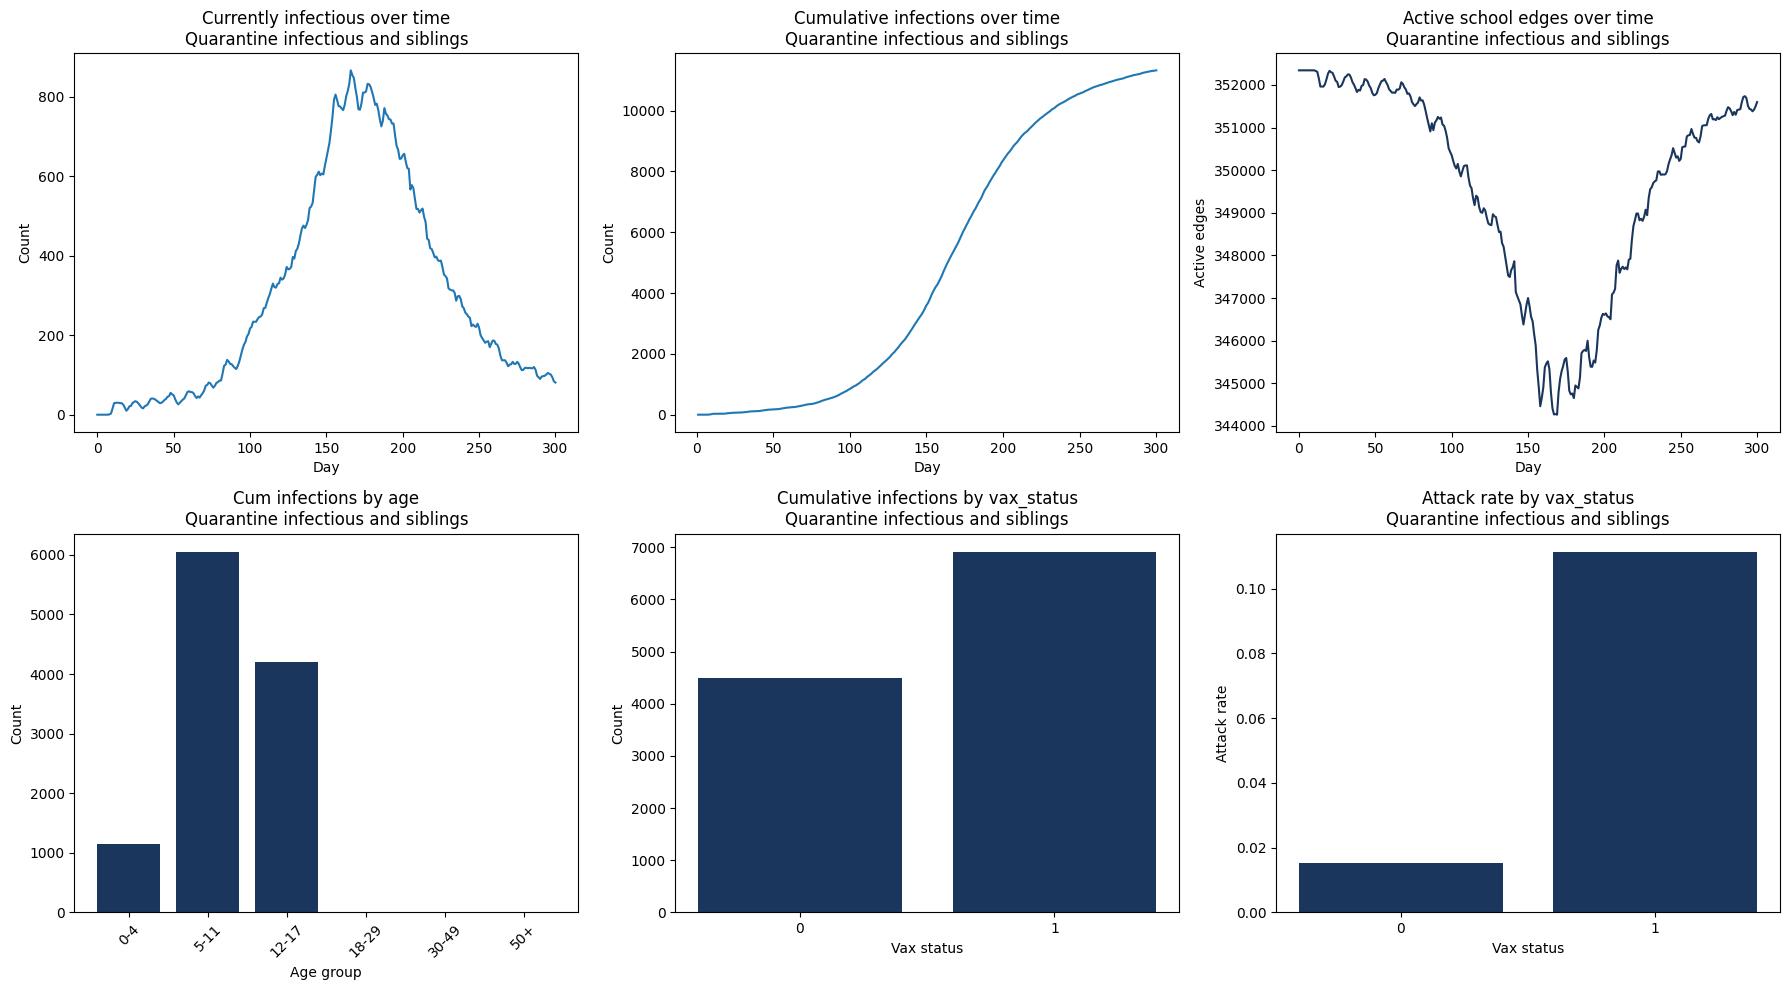

In [5]:
# Define children_df
children_df = get_children(ppl)

# Run Measles model with Quarantine siblings intervention
sim3 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s,],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [Quarantine_sib(days_since_infectious=3, # How many days after becoming infectious do people start quarantining? default=3
                                   days_quarantine=21, # How many days do people quarantine for? default=21
                                   compliance=1.0, # What proportion of siblings comply with quarantine? default=1
                                   children_df=children_df)], # Need dataframe of children by household, defined above
).run()

# Store results
res3 = sim3.results

# Plot results
plot_measles(sim3, res3, label='Quarantine infectious and siblings')

## 4.5 Quarantine contacts
The Quarantine contacts scenario is probably most realistic and comparable to contact tracing. It simulates quarantining an infectious individual and all of their contacts at home and at school. Here's the logic:

* Identify infectious individuals and their contacts at home and at school by referencing household id and sch_code in `children_df`
* If `days_since_infectious` of index case has passed, mark index case and contacts as quarantining until `dur_quarantine` passes
* While quarantined, set the edge_weight of their contacts in the school network to 0 (home network contacts remain)
* The proportion of contacts who comply with quarantine is set with `compliance`
* The index infectious agent always isolates
* Only unvaccinated contacts must quarantine

It may be unrealistic to catch every single contact of an infecitous individual so `compliance` is set to 0.7 as the default value. 

This class is called `Quarantine_contacts()` and is stored in `measles_geopops.py`. 

Initializing sim with 356923 agents
Initializing sim with 356923 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.18 s)  ———————————————————— 4%
  Running 20.0 (20/301) (0.43 s)  •——————————————————— 7%
  Running 30.0 (30/301) (0.70 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (0.93 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (1.21 s)  •••————————————————— 17%
  Running 60.0 (60/301) (1.47 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (1.75 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (2.04 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (2.34 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (2.64 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (2.95 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (3.24 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (3.57 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (3.90 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (4.24 s)  •

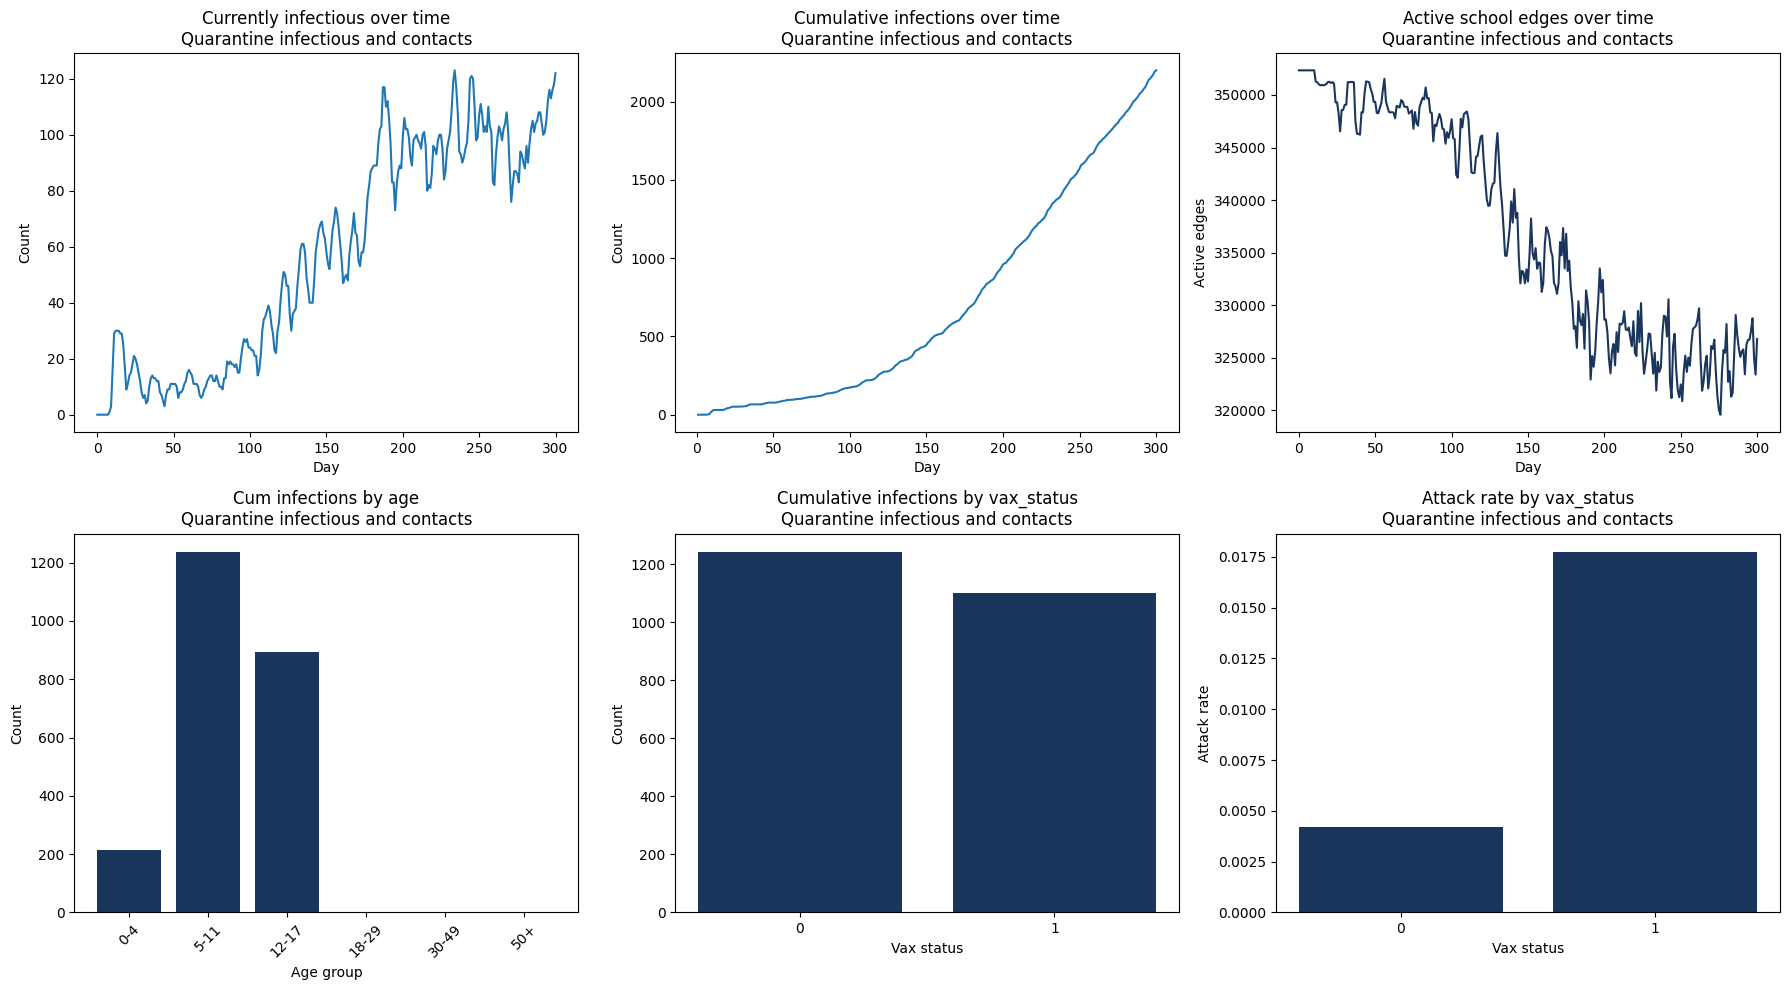

In [6]:
# Define children_df
children_df = get_children(ppl)

# Run Measles model with with Quarantine contacts intervention
sim4 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s,],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [Quarantine_contacts(days_since_infectious=3, # How many days after becoming infectious do people start quarantining? default=3
                                         dur_quarantine=21, # How many days do people quarantine for? default=21
                                         compliance=0.9, # What proportion of infected individuals comply with quarantine? default=0.7
                                         children_df=children_df)], # Need dataframe of children by household and school, defined above
).run()

# Store results
res4 = sim4.results

# Plot results
plot_measles(sim4, res4, label='Quarantine infectious and contacts')

## 4.6 Close school of infectious
The Close schools intervention simulates closing the entire school of an infectious individual. Because all GeoPops and Starsim code is open source, AI-coding assistants can be super helpful in designing your own interventions. Here's the prompt I used to make a `CloseSchools()` ss.Intervention class that removes the school edges of all the agents in the same school as an infectious agent. It uses the same `days_since_infectious`, `days_quarantine`, and `chidlren_df` inputs. There is no `compliance`, assuming that a school will definitely close after detecting an infectious individual. 

**Cursor chat prompt:**
> Read @4_measles_quarantine.ipynb. The dataframe children_df lists all children uids, household id, and sch_id. I want to make a new ss.Intervention class called CloseSchools() which deactivates the edges of all the children in the same school as an infectious individual. It will have the same input arguments of days_since_infectious and days_quarantine. Print suggested code in chat.

I copied and pasted the code below. It worked on the first try! But I had to add the lists for tracking the number of quarantined and active school edges (used in plotting). I also changed it so that the edge_weights were not hardcoded as 1 but so it used the edge_weights in from networks defined previously. AI will get better and better at coding, but it is still our responsibility as modelers to go through generated code and run tests to make sure things are working as intended.

In [7]:
class CloseSchools(ss.Intervention):
    def __init__(self, *args,
                 days_since_infectious=1,
                 days_quarantine=7,
                 children_df=None,
                 **kwargs):
        """
        Close entire schools for a fixed window after any student becomes infectious.

        Args:
            days_since_infectious: offset (in days) after infection when school closure starts
            days_quarantine: duration (in days) that affected schools remain closed
            children_df: DataFrame with at least ['uid', 'sch_code'] for school-attending agents
        """
        super().__init__(*args, **kwargs)
        self.days_since_infectious = days_since_infectious
        self.days_quarantine = days_quarantine
        self.children = children_df  # uid, household, sch_code (uid as int)

        # Tracking
        self.school_edges = []          # number of active school edges per day
        # Number of students quarantined each day (i.e., students attending schools that are closed today)
        # Kept for compatibility with notebook plots.
        self.quarantined = []
        self.closed_schools = []        # list of sets of closed schools per day (optional)

        # Internal: map uid -> school id, and school id -> student uids
        self._uid_to_school = None
        self._school_to_uids = None
        self._school_closed_until = {}  # sch_code -> day (float) until which it remains closed
        self._beta0 = None               # baseline school network edge weights

    def init_pre(self, sim):
        super().init_pre(sim)
        if self.children is None:
            raise RuntimeError("CloseSchool requires children_df with columns ['uid', 'sch_code'].")

        df = self.children.copy()
        df = df.dropna(subset=['sch_code'])
        df['uid'] = df['uid'].astype(int)
        df['ssch_codeh_id'] = df['sch_code'].astype(int)

        # uid -> sch_code
        self._uid_to_school = dict(zip(df['uid'].values, df['sch_code'].values))

        # sch_code -> np.ndarray of uids
        self._school_to_uids = {
            sch: grp['uid'].to_numpy(dtype=int)
            for sch, grp in df.groupby('sch_code')
        }

        # Snapshot baseline edge weights so we can restore them each step
        net = sim.networks['schoolnet']
        self._beta0 = net.edges.beta.copy()
        return

    def step(self):
        sim = self.sim
        net = sim.networks['schoolnet']
        ti = sim.ti

        # Shortcuts to network arrays
        p1 = net.edges.p1
        p2 = net.edges.p2
        beta = net.edges.beta

        # Restore baseline before applying any school closure edge changes
        if self._beta0 is None:
            self._beta0 = beta.copy()
        beta[:] = self._beta0

        # --- 1) Update which schools should be closed based on current infections ---

        infected = sim.people.measles.infected
        ti_infected = sim.people.measles.ti_infected
        days_since_infected = ti - ti_infected

        # Base infectious students in the quarantine window
        base_quarantined = (
            infected
            & (days_since_infected >= self.days_since_infectious)
            & (days_since_infected < self.days_since_infectious + self.days_quarantine)
        )
        base_uids = ss.uids(base_quarantined)  # Starsim UIDs

        # For any such infected student with a known school, extend that school’s closure window
        if len(base_uids):
            for uid in base_uids:
                uid_int = int(uid)
                sch_code = self._uid_to_school.get(uid_int, None)
                if sch_code is None:
                    continue
                # Close this school until (ti + days_quarantine) at least
                current_until = self._school_closed_until.get(sch_code, -np.inf)
                self._school_closed_until[sch_code] = max(current_until, ti + self.days_quarantine)

        # --- 2) Determine which schools are closed on this day ---

        closed_schools_today = {
            sch for sch, t_until in self._school_closed_until.items() if ti < t_until
        }

        # Optionally record closed school set
        self.closed_schools.append(closed_schools_today.copy())

        # --- 3) Compute which UIDs are in closed schools today ---

        if closed_schools_today:
            # Union of all student UIDs for closed schools
            closed_uids_list = [
                self._school_to_uids[sch]
                for sch in closed_schools_today
                if sch in self._school_to_uids
            ]
            if closed_uids_list:
                closed_uids = np.unique(np.concatenate(closed_uids_list))
            else:
                closed_uids = np.empty(0, dtype=int)
        else:
            closed_uids = np.empty(0, dtype=int)

        # --- 3b) Track quarantined students today ---
        self.quarantined.append(int(closed_uids.size))

        # --- 4) Apply closure to the school network edges ---

        if closed_uids.size > 0:
            mask_disable = np.isin(p1, closed_uids) | np.isin(p2, closed_uids)
        else:
            mask_disable = np.zeros(len(p1), dtype=bool)

        beta[mask_disable] = np.zeros_like(beta[mask_disable])

        # --- 5) Track active school edges ---

        self.school_edges.append(int(np.count_nonzero(beta)))
        return


Now pass this into the sim and run.

Initializing sim with 356923 agents
  Running 0.0 ( 0/301) (0.00 s)  ———————————————————— 0%
  Running 10.0 (10/301) (0.20 s)  ———————————————————— 4%
  Running 20.0 (20/301) (0.41 s)  •——————————————————— 7%
  Running 30.0 (30/301) (0.62 s)  ••—————————————————— 10%
  Running 40.0 (40/301) (0.80 s)  ••—————————————————— 14%
  Running 50.0 (50/301) (0.98 s)  •••————————————————— 17%
  Running 60.0 (60/301) (1.19 s)  ••••———————————————— 20%
  Running 70.0 (70/301) (1.37 s)  ••••———————————————— 24%
  Running 80.0 (80/301) (1.54 s)  •••••——————————————— 27%
  Running 90.0 (90/301) (1.71 s)  ••••••—————————————— 30%
  Running 100.0 (100/301) (1.87 s)  ••••••—————————————— 34%
  Running 110.0 (110/301) (2.02 s)  •••••••————————————— 37%
  Running 120.0 (120/301) (2.18 s)  ••••••••———————————— 40%
  Running 130.0 (130/301) (2.34 s)  ••••••••———————————— 44%
  Running 140.0 (140/301) (2.49 s)  •••••••••——————————— 47%
  Running 150.0 (150/301) (2.64 s)  ••••••••••—————————— 50%
  Running 16

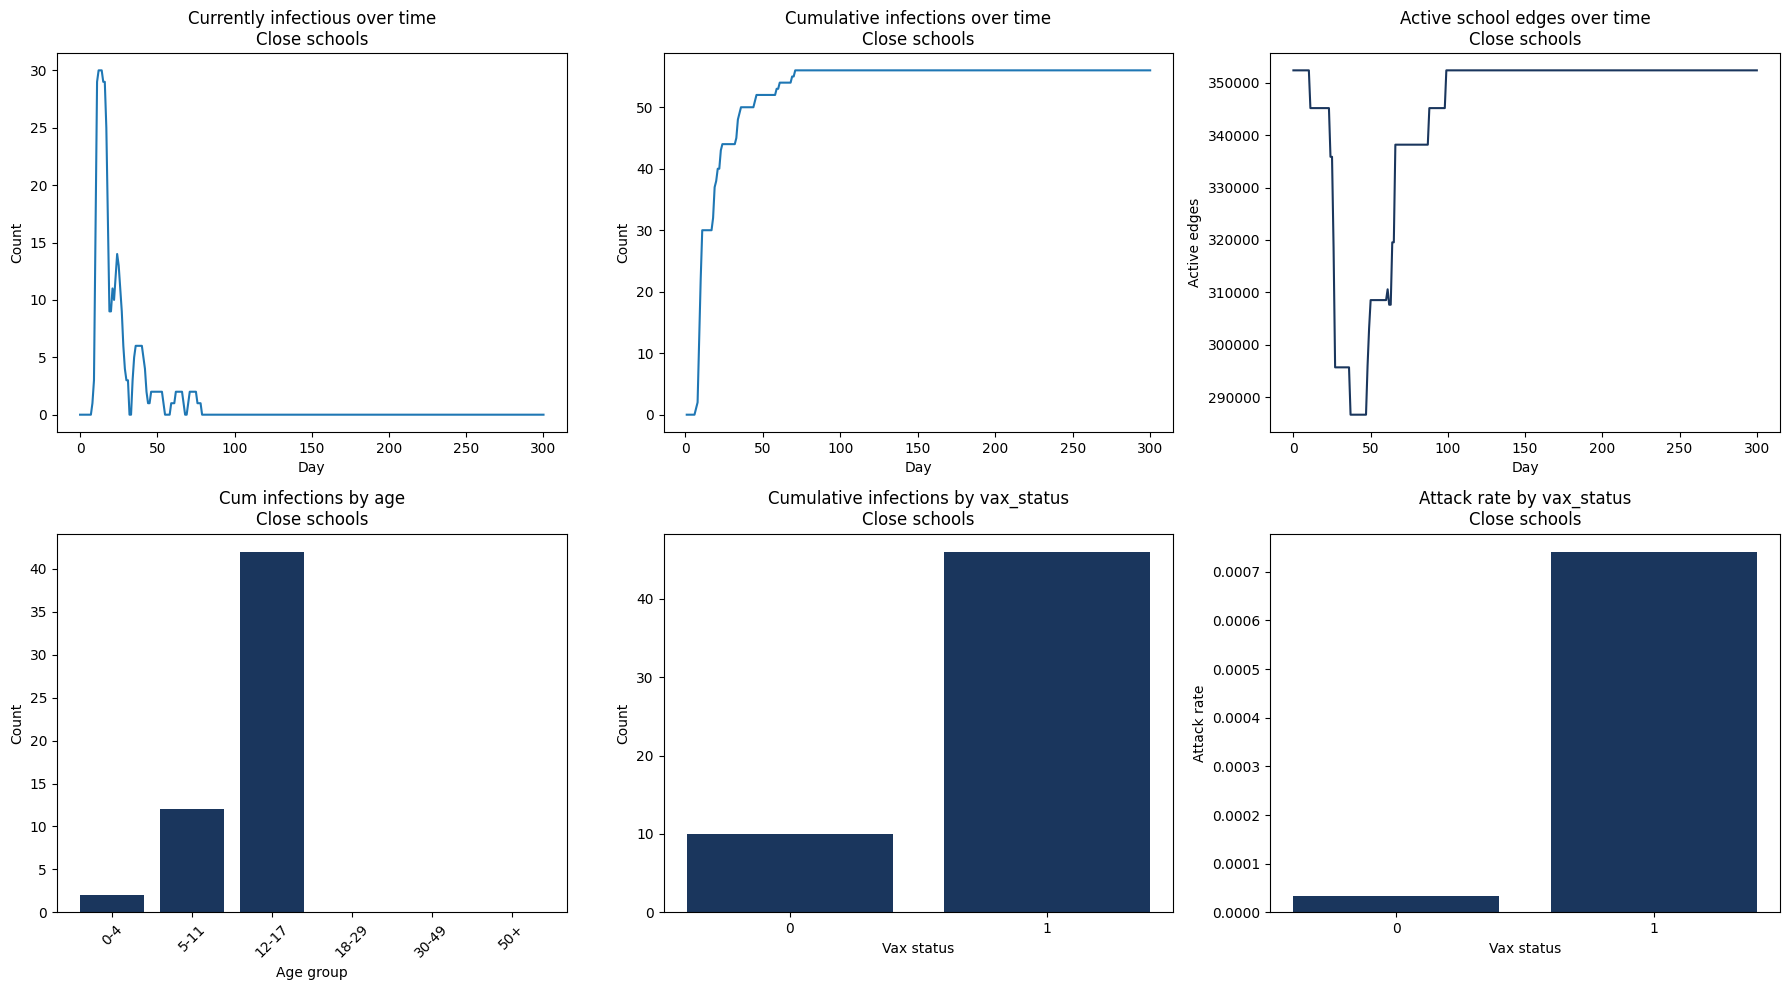

In [8]:
# Run Measles model with CloseSchools intervention
sim5 = ss.Sim(
    pars    = sc.objdict(start = 0, stop  =300, dt = 1.0),
    people  = ppl,
    networks = [h, s,],
    diseases = [Measles(measles_pars)],
    ############################## SET QUARANTINE PARAMETERS HERE ##############################
    interventions = [CloseSchools(days_since_infectious=3, # How many days after becoming infectious do people start quarantining?
                                   days_quarantine=21, # How many days do people quarantine for?
                                   children_df=children_df)], # Need dataframe of children by household
).run()

# Store results
res5 = sim5.results

# Plot results
plot_measles(sim5, res5, label='Close schools')

## 4.7 Plot comparisons
Let's plot comparisons of all the quarantine strategies.

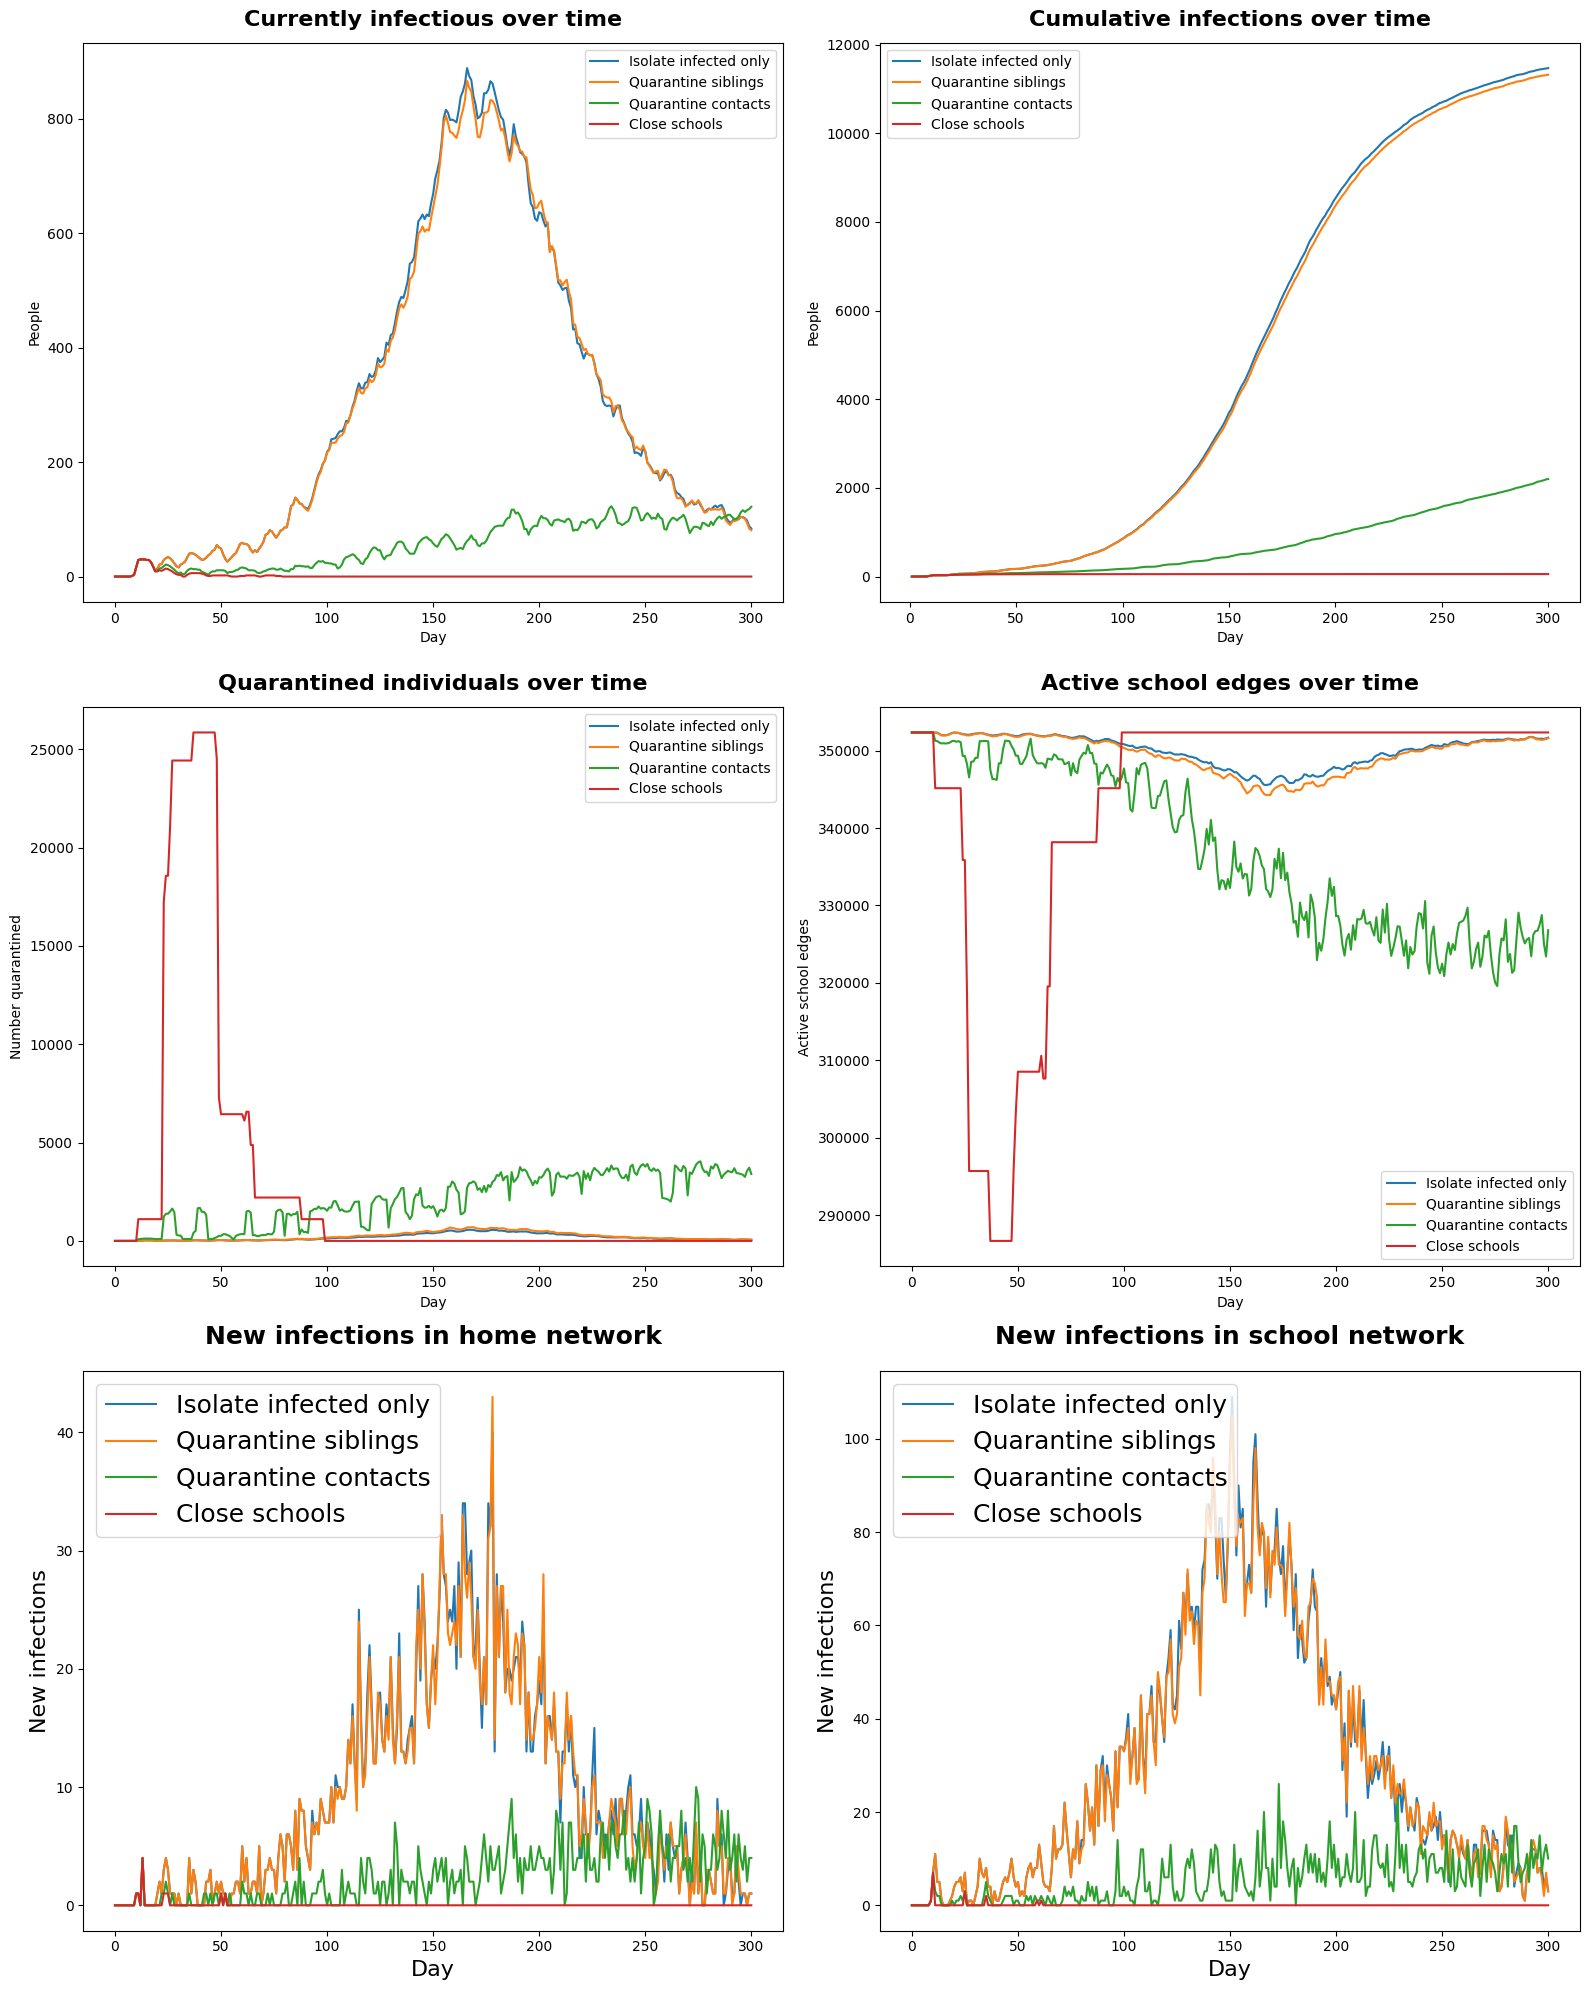

In [ ]:
# 6-panel comparison figure using the same objects already in this notebook:
# res2/res3/res4/res5 and sim2/sim3/sim4/sim5

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.ravel()

# Keep strategy labels and objects together
strategies = [
    ("Isolate infected only", res2, sim2),
    ("Quarantine siblings",   res3, sim3),
    ("Quarantine contacts",   res4, sim4),
    ("Close schools",         res5, sim5),
]

# -----------------------------
# 1) Currently infectious over time
# -----------------------------
ax = axes[0]
for label, res, sim in strategies:
    ax.plot(res.timevec, res.measles.n_infected, label=label)
ax.set_title("Currently infectious over time", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Day")
ax.set_ylabel("People")
ax.legend()

# -----------------------------
# 2) Cumulative infections over time
# -----------------------------
ax = axes[1]
for label, res, sim in strategies:
    ax.plot(res.timevec[1:], res.measles.new_infections[1:].cumsum(), label=label)
ax.set_title("Cumulative infections over time", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Day")
ax.set_ylabel("People")
ax.legend()

# Pull interventions and network infection arrays once
q2, q3, q4, q5 = sim2.interventions[0], sim3.interventions[0], sim4.interventions[0], sim5.interventions[0]

# network index assumptions:
# 0=home, 1=school, 2=work, 3=gq, 4=between-school
sim2_infs_h = res2["measles"].new_infections_by_network[:, 0]
sim2_infs_s = res2["measles"].new_infections_by_network[:, 1]
# sim2_infs_bs = res2["measles"].new_infections_by_network[:, 2]

sim3_infs_h = res3["measles"].new_infections_by_network[:, 0]
sim3_infs_s = res3["measles"].new_infections_by_network[:, 1]
# sim3_infs_bs = res3["measles"].new_infections_by_network[:, 2]

sim4_infs_h = res4["measles"].new_infections_by_network[:, 0]
sim4_infs_s = res4["measles"].new_infections_by_network[:, 1]
# sim4_infs_bs = res4["measles"].new_infections_by_network[:, 2]

sim5_infs_h = res5["measles"].new_infections_by_network[:, 0]
sim5_infs_s = res5["measles"].new_infections_by_network[:, 1]
# sim5_infs_bs = res5["measles"].new_infections_by_network[:, 2]

# -----------------------------
# 3) Quarantined individuals over time
# -----------------------------
ax = axes[2]
days_q2 = sim2.results.timevec[:len(q2.quarantined)]
days_q3 = sim3.results.timevec[:len(q3.quarantined)]
days_q4 = sim4.results.timevec[:len(q4.quarantined)]
days_q5 = sim5.results.timevec[:len(q5.quarantined)]
ax.plot(days_q2, q2.quarantined, label="Isolate infected only")
ax.plot(days_q3, q3.quarantined, label="Quarantine siblings")
ax.plot(days_q4, q4.quarantined, label="Quarantine contacts")
ax.plot(days_q5, q5.quarantined, label="Close schools")
ax.set_title("Quarantined individuals over time", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Day")
ax.set_ylabel("Number quarantined")
ax.legend()

# -----------------------------
# 4) Active school edges over time
# -----------------------------
ax = axes[3]
days_e2 = sim2.results.timevec[:len(q2.school_edges)]
days_e3 = sim3.results.timevec[:len(q3.school_edges)]
days_e4 = sim4.results.timevec[:len(q4.school_edges)]
days_e5 = sim5.results.timevec[:len(q5.school_edges)]
ax.plot(days_e2, q2.school_edges, label="Isolate infected only")
ax.plot(days_e3, q3.school_edges, label="Quarantine siblings")
ax.plot(days_e4, q4.school_edges, label="Quarantine contacts")
ax.plot(days_e5, q5.school_edges, label="Close schools")
ax.set_title("Active school edges over time", fontsize=16, fontweight="bold", pad=12)
ax.set_xlabel("Day")
ax.set_ylabel("Active school edges")
ax.legend()

# -----------------------------
# 5) New infections in home network
# -----------------------------
ax = axes[4]
ax.plot(res2.timevec, sim2_infs_h, label="Isolate infected only")
ax.plot(res3.timevec, sim3_infs_h, label="Quarantine siblings")
ax.plot(res4.timevec, sim4_infs_h, label="Quarantine contacts")
ax.plot(res5.timevec, sim5_infs_h, label="Close schools")
ax.set_title("New infections in home network", fontsize=18, weight="bold", pad=20)
ax.set_xlabel("Day", fontsize=16)
ax.set_ylabel("New infections", fontsize=16)
ax.legend(fontsize=18)

# -----------------------------
# 6) New infections in school network
# -----------------------------
ax = axes[5]
ax.plot(res2.timevec, sim2_infs_s, label="Isolate infected only")
ax.plot(res3.timevec, sim3_infs_s, label="Quarantine siblings")
ax.plot(res4.timevec, sim4_infs_s, label="Quarantine contacts")
ax.plot(res5.timevec, sim5_infs_s, label="Close schools")
ax.set_title("New infections in school network", fontsize=18, weight="bold", pad=20)
ax.set_xlabel("Day", fontsize=16)
ax.set_ylabel("New infections", fontsize=16)
ax.legend(fontsize=18)

# -----------------------------
# 7) New infections in between-school network
# -----------------------------
# ax = axes[6]
# ax.plot(res2.timevec, sim2_infs_bs, label="Isolate infected only")
# ax.plot(res3.timevec, sim3_infs_bs, label="Quarantine siblings")
# ax.plot(res4.timevec, sim4_infs_bs, label="Quarantine contacts")
# ax.plot(res5.timevec, sim5_infs_bs, label="Close schools")
# ax.set_title("New infections in between-school network", fontsize=18, weight="bold", pad=20)
# ax.set_xlabel("Day", fontsize=16)
# ax.set_ylabel("New infections", fontsize=16)
# ax.legend(fontsize=18)

# Hide the unused 8th panel
# axes[7].axis("off")

fig.tight_layout()
plt.show()

## 4.8 Interpreting results
According to the model and underlying network structure (with all their assumptions!), 
* Closing schools (or remote learning) for a period of time after a student gets infected has more of an impact than the other strategies. This makes sense given our assumption that the first exposed cases are at one school. 
* Quarantining siblings is not much improvement over quarantining the infectious individual even if we assume 100% siblings comply. This is likely because all the onward transmissions have already happened during the window that the index agent is infectious but not isolating. 

### What's next?
Obviously, these results do not match the confirm case counts reported by [SC DPH](https://github.com/GeoPopsHub/sc_spartanburg_measles/blob/main/GeoPops_Measles.pdf). Even though our model has a lot of parameters and is pretty complex, it is still a very simplified picture of what's actually going on in a measles outbreak (but could still inform decisions!). 

What other factors would be important to incorporate to make scenarios more realistic? Given what you understand about how GeoPops and Starsim work together, brainstorm how you would implement these factors into the network and modeling structure. What data would you need?

| Example Idea | Implementation | Data |
| -------- | -------- | -------- | 
| Model all of SC not just Spartanburg | Run GeoPops for all of SC, or even better, SC and surrounding states | Have all the data. Will just take a long time to run, but only need to run it once! |
| Assign immunization rates by school | Factor this into the vax_status attribute (see `2_explore_people.ipynb`) | Vaccination rates by school | 
| Make a sporting events network | Could probabilisticly assign some agents to participate in weekly "sporting events" with agents from other schools. Then pass this network into the sim with the other networks | Sports participation data? Which schools compete against each other? |

* **What else can you think of?**
* **What other interventions might you want to model besides quarantine?**

Previous notebook: [4_measles_seeding.ipynb](https://github.com/GeoPopsHub/sc_spartanburg_measles/blob/main/4_measles_seeding.ipynb)




